
# Human Study Analysis

This notebook analyzes the two tidy files generated by `reshape_survey_results.py`:

- `human_ratings_long.csv`: one row per participant × argument × displayed method.
- `argument_ratings.csv`: one row per participant × argument.

The analysis is primarily descriptive because the expected sample size is small.  
For method-level comparisons, ratings are additionally aggregated to **participant × method** before computing group summaries, so repeated ratings from the same participant are not treated as independent observations.

The notebook covers:

1. Study and response overview
2. Overall inappropriateness ratings
3. Relevance, Sufficiency, Completeness, and Precision by method
4. Participant-level and argument-level variation
5. Method preferences
6. Exploratory repeated-measures tests
7. Export of compact summary tables


In [ ]:

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from IPython.display import display

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

CURRENT_DIR = Path.cwd()
REPO_ROOT = CURRENT_DIR.parent

HUMAN_STUDY_DIR = REPO_ROOT / "human_study"
RESULT_DIR = HUMAN_STUDY_DIR / "survey_results"
OUTPUT_DIR = REPO_ROOT / "results/survey_results"

RATINGS_PATH = RESULT_DIR / "human_ratings_long.csv"
ARGUMENTS_PATH = RESULT_DIR / "argument_ratings.csv"

FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "analysis_tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Reading results from: {RATINGS_PATH} and {ARGUMENTS_PATH}")
print(f"Writing results to: {OUTPUT_DIR}")

In [36]:
METHOD_ORDER = [
    "random",
    "tfidf",
    "attention",
    "ig",
    "shap",
    "mil",
    "llm",
]

METHOD_LABELS = {
    "random": "Random",
    "tfidf": "TF-IDF",
    "attention": "Attention",
    "ig": "Integrated Gradients",
    "shap": "SHAP",
    "mil": "MIL",
    "llm": "LLM",
}

CRITERIA = [
    "relevance",
    "sufficiency",
    "completeness",
    "precision",
]

CRITERION_LABELS = {
    "relevance": "Relevance",
    "sufficiency": "Sufficiency",
    "completeness": "Completeness",
    "precision": "Precision",
}

ratings = pd.read_csv(RATINGS_PATH)
arguments = pd.read_csv(ARGUMENTS_PATH)

for col in [
    "overall_inappropriateness",
    "relevance",
    "sufficiency",
    "completeness",
    "precision",
]:
    if col in ratings.columns:
        ratings[col] = pd.to_numeric(ratings[col], errors="coerce")

if "overall_inappropriateness" in arguments.columns:
    arguments["overall_inappropriateness"] = pd.to_numeric(
        arguments["overall_inappropriateness"],
        errors="coerce",
    )

ratings["method_label"] = ratings["method_id"].map(METHOD_LABELS).fillna(
    ratings["method_id"]
)

print("human_ratings_long:", ratings.shape)
print("argument_ratings:", arguments.shape)
display(ratings.head())

human_ratings_long: (42, 20)
argument_ratings: (14, 12)


,response_id,version,lime_seed,display_position,argument_index,global_row_id,method_id,display_label,overall_inappropriateness,relevance,sufficiency,completeness,precision,preferred_display_label,preferred_method,is_preferred,comment,issue,post_text,method_label
0,2,1,1205913802,1,1,2181,shap,A,6,4,4,5,3,C,attention,False,NaN,Do you think that the government should be abl...,Absolutely not. It's the first step down a sli...,SHAP
1,2,1,1205913802,1,1,2181,ig,B,6,4,4,4,2,C,attention,False,NaN,Do you think that the government should be abl...,Absolutely not. It's the first step down a sli...,Integrated Gradients
2,2,1,1205913802,1,1,2181,attention,C,6,4,4,5,3,C,attention,True,NaN,Do you think that the government should be abl...,Absolutely not. It's the first step down a sli...,Attention
3,2,1,1205913802,2,2,2107,tfidf,A,5,6,6,5,3,A,tfidf,True,NaN,India has the potential to lead the world:,India does not have the potential to lead the ...,TF-IDF
4,2,1,1205913802,2,2,2107,shap,B,5,5,5,5,2,A,tfidf,False,NaN,India has the potential to lead the world:,India does not have the potential to lead the ...,SHAP


## 1. Study overview

In [13]:

n_participants = ratings["response_id"].nunique()
n_argument_trials = arguments[["response_id", "global_row_id"]].drop_duplicates().shape[0]
n_explanation_ratings = len(ratings)

overview = pd.DataFrame(
    {
        "Measure": [
            "Participants",
            "Argument trials",
            "Explanation ratings",
            "Unique arguments",
            "Methods",
        ],
        "Value": [
            n_participants,
            n_argument_trials,
            n_explanation_ratings,
            ratings["global_row_id"].nunique(),
            ratings["method_id"].nunique(),
        ],
    }
)

display(overview)

responses_per_participant = (
    ratings.groupby("response_id")
    .agg(
        version=("version", "first"),
        n_arguments=("global_row_id", "nunique"),
        n_explanations=("method_id", "size"),
        n_methods=("method_id", "nunique"),
    )
    .reset_index()
)

display(responses_per_participant)


,Measure,Value
0,Participants,2
1,Argument trials,14
2,Explanation ratings,42
3,Unique arguments,7
4,Methods,7


,response_id,version,n_arguments,n_explanations,n_methods
0,2,1,7,21,7
1,3,7,7,21,7


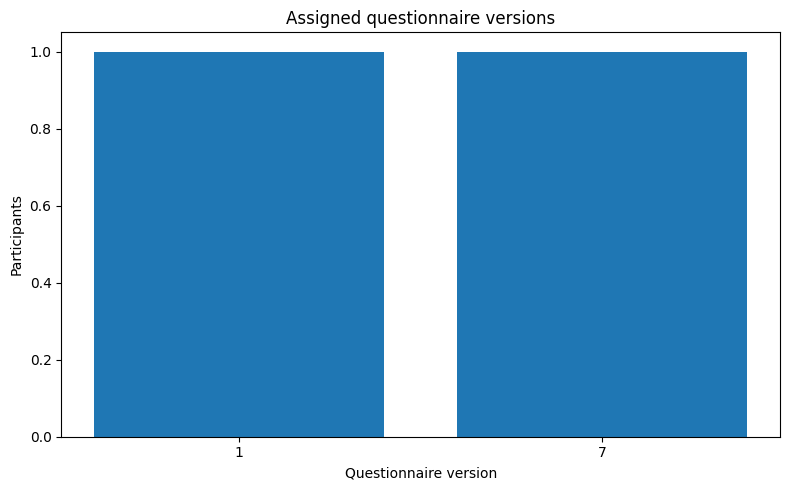

In [14]:

# Distribution of assigned questionnaire versions

version_counts = (
    ratings[["response_id", "version"]]
    .drop_duplicates()
    ["version"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))
plt.bar(version_counts.index.astype(str), version_counts.values)
plt.xlabel("Questionnaire version")
plt.ylabel("Participants")
plt.title("Assigned questionnaire versions")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "version_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


### Missing / non-assessable ratings

In [15]:

missing_summary = pd.DataFrame(
    {
        "criterion": CRITERIA,
        "n_missing": [ratings[c].isna().sum() for c in CRITERIA],
        "missing_rate": [ratings[c].isna().mean() for c in CRITERIA],
    }
)

display(missing_summary)


,criterion,n_missing,missing_rate
0,relevance,0,0.0
1,sufficiency,0,0.0
2,completeness,0,0.0
3,precision,0,0.0


## 2. Overall inappropriateness

Valid overall ratings: 14
Mean: 5.071428571428571
Median: 5.0
Std: 1.2688144505364485


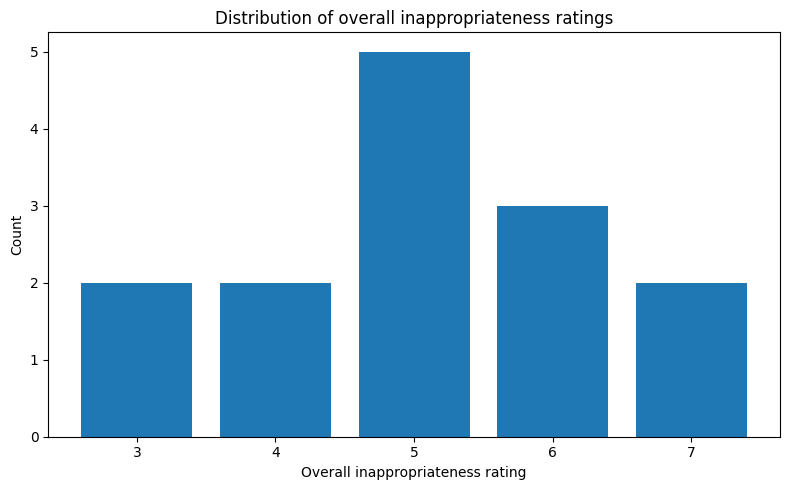

In [16]:

overall = arguments["overall_inappropriateness"].dropna()

print("Valid overall ratings:", len(overall))
print("Mean:", overall.mean())
print("Median:", overall.median())
print("Std:", overall.std())

counts = overall.value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(counts.index.astype(int).astype(str), counts.values)
plt.xlabel("Overall inappropriateness rating")
plt.ylabel("Count")
plt.title("Distribution of overall inappropriateness ratings")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "overall_inappropriateness_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


,global_row_id,n_ratings,mean_inappropriateness,median_inappropriateness,std_inappropriateness
5,2172,2,7.0,7.0,0.000000
3,2049,2,5.5,5.5,0.707107
4,2107,2,5.5,5.5,0.707107
6,2181,2,5.5,5.5,0.707107
0,1785,2,4.5,4.5,0.707107
2,2014,2,4.5,4.5,0.707107
1,1921,2,3.0,3.0,0.000000


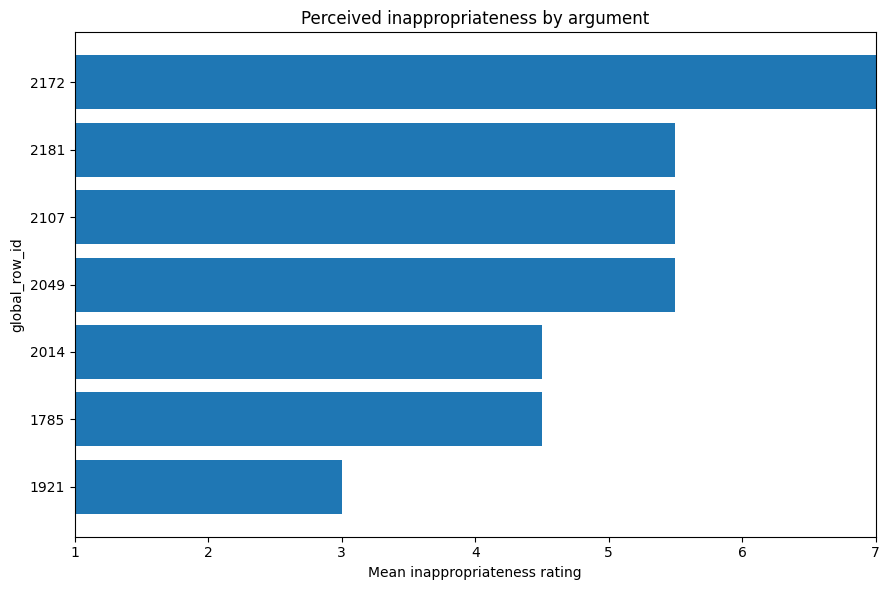

In [17]:

# Mean perceived inappropriateness per argument

argument_inappropriateness = (
    arguments.groupby("global_row_id", as_index=False)
    .agg(
        n_ratings=("overall_inappropriateness", "count"),
        mean_inappropriateness=("overall_inappropriateness", "mean"),
        median_inappropriateness=("overall_inappropriateness", "median"),
        std_inappropriateness=("overall_inappropriateness", "std"),
    )
    .sort_values("mean_inappropriateness", ascending=False)
)

display(argument_inappropriateness)

plot_df = argument_inappropriateness.sort_values("mean_inappropriateness")

plt.figure(figsize=(9, 6))
plt.barh(
    plot_df["global_row_id"].astype(str),
    plot_df["mean_inappropriateness"],
)
plt.xlim(1, 7)
plt.xlabel("Mean inappropriateness rating")
plt.ylabel("global_row_id")
plt.title("Perceived inappropriateness by argument")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "overall_inappropriateness_by_argument.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()



## 3. Human ratings by localization method

The main descriptive method comparison uses **participant-level method means**:

\[
ar{x}_{p,m,c}
\]

for participant \(p\), method \(m\), and criterion \(c\).

This avoids counting three ratings from the same participant for one method as three independent observations.


In [18]:

participant_method = (
    ratings.groupby(["response_id", "method_id"], as_index=False)[CRITERIA]
    .mean()
)

participant_method["method_label"] = (
    participant_method["method_id"]
    .map(METHOD_LABELS)
    .fillna(participant_method["method_id"])
)

display(participant_method.head(14))


,response_id,method_id,relevance,sufficiency,completeness,precision,method_label
0,2,attention,5.333333,5.000000,4.666667,4.333333,Attention
1,2,ig,4.000000,3.666667,3.666667,1.666667,Integrated Gradients
2,2,llm,5.333333,4.666667,4.000000,5.666667,LLM
3,2,mil,5.666667,6.000000,6.333333,1.000000,MIL
4,2,random,3.666667,3.666667,3.666667,1.333333,Random
5,2,shap,3.666667,3.666667,4.000000,2.333333,SHAP
6,2,tfidf,4.666667,4.666667,4.333333,3.333333,TF-IDF
7,3,attention,5.666667,5.333333,4.000000,3.666667,Attention
8,3,ig,4.666667,4.666667,4.000000,3.333333,Integrated Gradients
9,3,llm,7.000000,5.666667,5.333333,6.666667,LLM


In [19]:

def mean_ci(series, confidence=0.95):
    values = pd.Series(series).dropna().astype(float)

    n = len(values)
    if n == 0:
        return pd.Series(
            {"n": 0, "mean": np.nan, "std": np.nan, "ci_low": np.nan, "ci_high": np.nan}
        )

    mean = values.mean()
    std = values.std(ddof=1) if n > 1 else np.nan

    if n > 1:
        sem = stats.sem(values)
        margin = stats.t.ppf((1 + confidence) / 2, df=n - 1) * sem
        ci_low = mean - margin
        ci_high = mean + margin
    else:
        ci_low = np.nan
        ci_high = np.nan

    return pd.Series(
        {
            "n": n,
            "mean": mean,
            "std": std,
            "ci_low": ci_low,
            "ci_high": ci_high,
        }
    )


summary_rows = []

for method in METHOD_ORDER:
    method_df = participant_method[
        participant_method["method_id"] == method
    ]

    for criterion in CRITERIA:
        summary = mean_ci(method_df[criterion])

        summary_rows.append(
            {
                "method_id": method,
                "method": METHOD_LABELS.get(method, method),
                "criterion": criterion,
                "criterion_label": CRITERION_LABELS[criterion],
                **summary.to_dict(),
            }
        )

method_summary = pd.DataFrame(summary_rows)
display(method_summary)

method_summary.to_csv(
    TABLE_DIR / "method_rating_summary.csv",
    index=False,
)


,method_id,method,criterion,criterion_label,n,mean,std,ci_low,ci_high
0,random,Random,relevance,Relevance,2.0,3.333333,0.471405,-0.902068,7.568735
1,random,Random,sufficiency,Sufficiency,2.0,3.166667,0.707107,-3.186436,9.519769
2,random,Random,completeness,Completeness,2.0,3.166667,0.707107,-3.186436,9.519769
3,random,Random,precision,Precision,2.0,1.333333,0.000000,1.333333,1.333333
4,tfidf,TF-IDF,relevance,Relevance,2.0,5.000000,0.471405,0.764598,9.235402
5,tfidf,TF-IDF,sufficiency,Sufficiency,2.0,5.166667,0.707107,-1.186436,11.519769
6,tfidf,TF-IDF,completeness,Completeness,2.0,5.000000,0.942809,-3.470803,13.470803
7,tfidf,TF-IDF,precision,Precision,2.0,2.166667,1.649916,-12.657239,16.990572
8,attention,Attention,relevance,Relevance,2.0,5.500000,0.235702,3.382299,7.617701
9,attention,Attention,sufficiency,Sufficiency,2.0,5.166667,0.235702,3.048966,7.284367


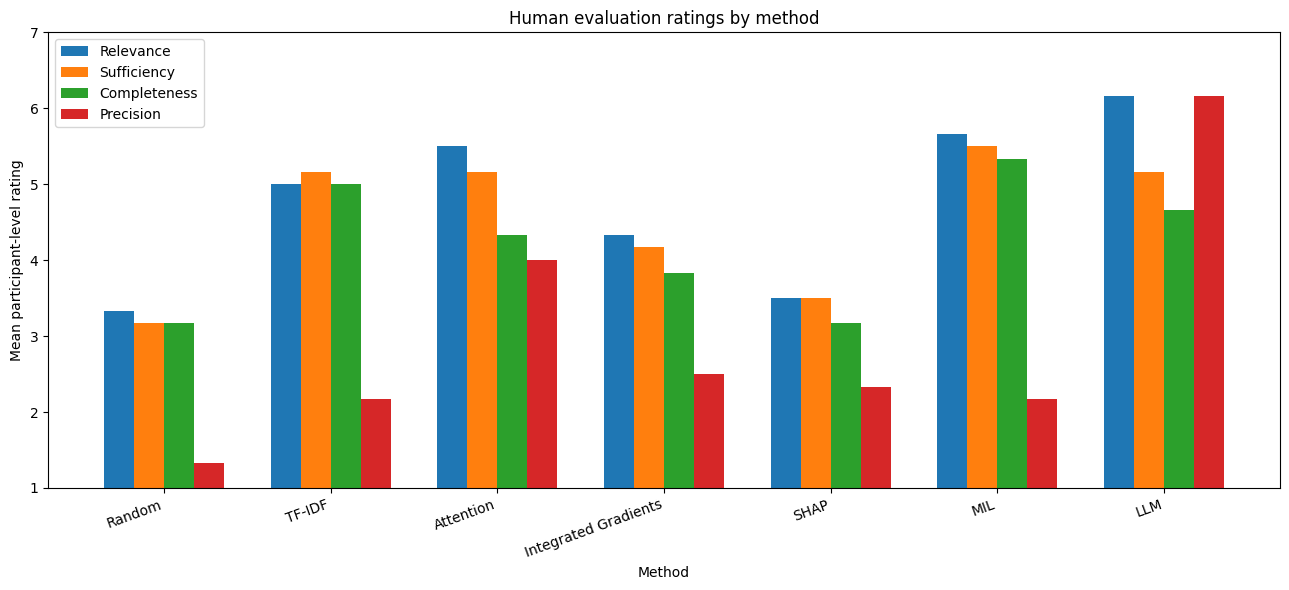

In [20]:

# Grouped bar chart: mean ratings across all four criteria

means = (
    method_summary
    .pivot(index="method", columns="criterion", values="mean")
    .reindex([METHOD_LABELS[m] for m in METHOD_ORDER])
)

x = np.arange(len(means.index))
width = 0.18

plt.figure(figsize=(13, 6))

for i, criterion in enumerate(CRITERIA):
    values = means[criterion].values
    offset = (i - (len(CRITERIA) - 1) / 2) * width
    plt.bar(
        x + offset,
        values,
        width=width,
        label=CRITERION_LABELS[criterion],
    )

plt.xticks(x, means.index, rotation=20, ha="right")
plt.ylim(1, 7)
plt.ylabel("Mean participant-level rating")
plt.xlabel("Method")
plt.title("Human evaluation ratings by method")
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "method_ratings_all_criteria.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


### Individual plots per criterion

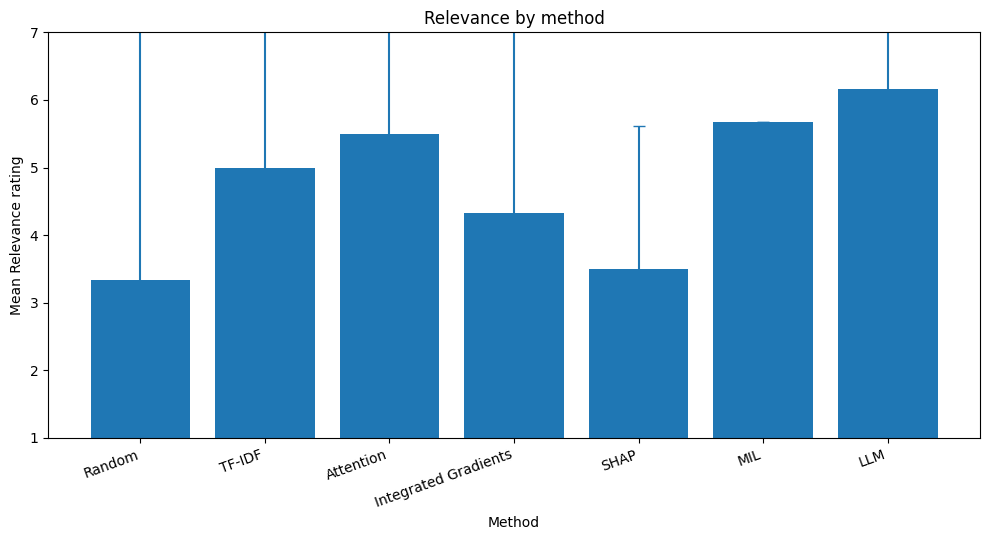

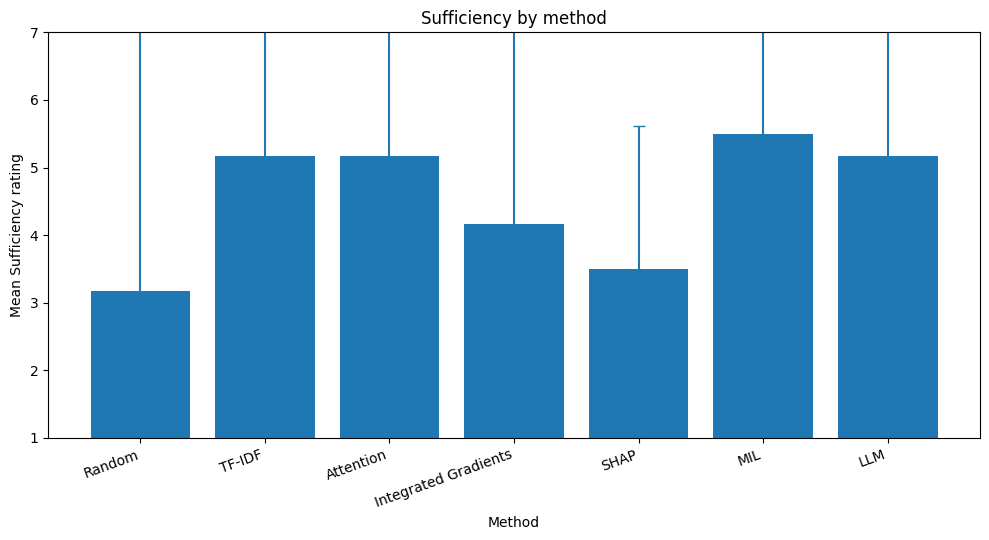

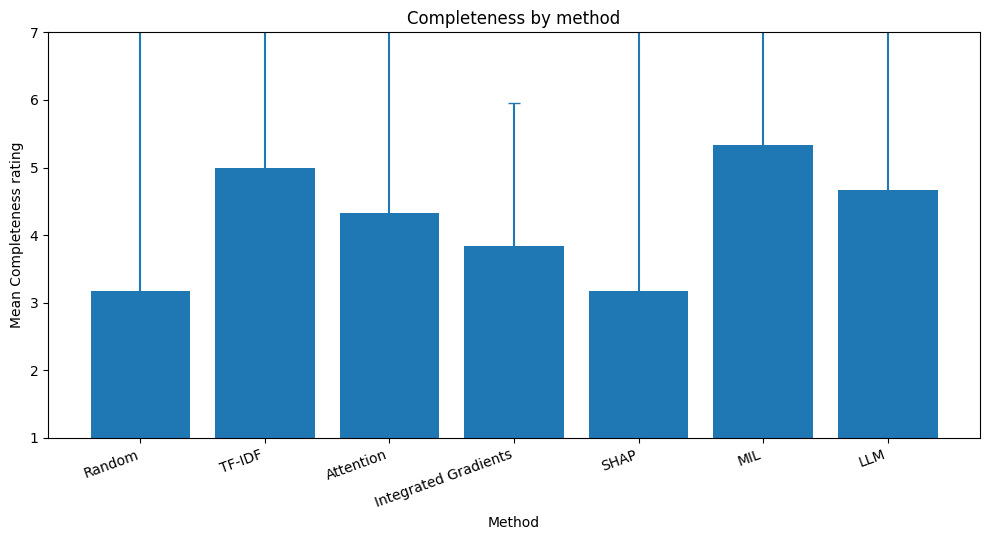

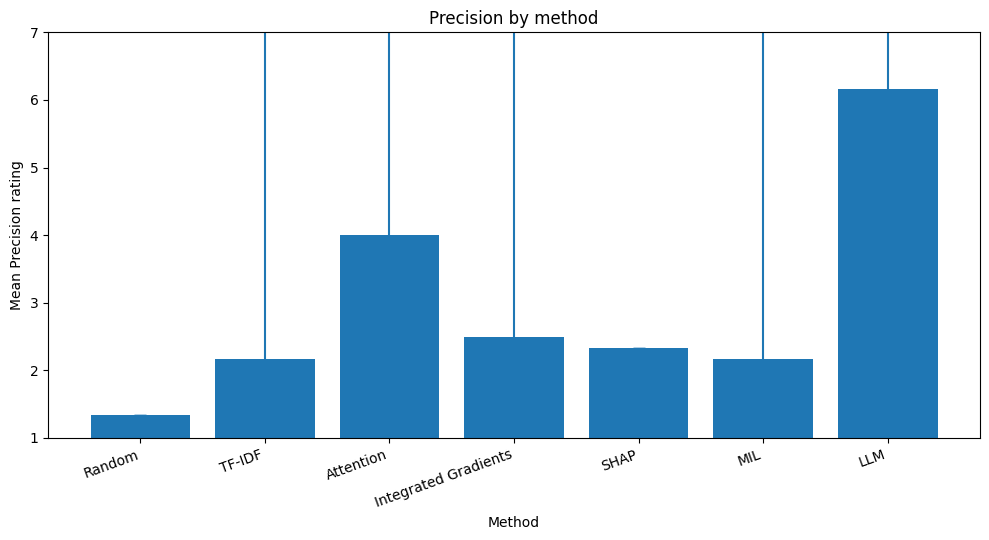

In [21]:

for criterion in CRITERIA:
    plot_df = method_summary[
        method_summary["criterion"] == criterion
    ].copy()

    plot_df["order"] = plot_df["method_id"].map(
        {method: i for i, method in enumerate(METHOD_ORDER)}
    )
    plot_df = plot_df.sort_values("order")

    means = plot_df["mean"].to_numpy(dtype=float)
    lower = means - plot_df["ci_low"].to_numpy(dtype=float)
    upper = plot_df["ci_high"].to_numpy(dtype=float) - means

    plt.figure(figsize=(10, 5.5))
    plt.bar(plot_df["method"], means)

    valid_ci = np.isfinite(lower) & np.isfinite(upper)
    if valid_ci.any():
        positions = np.arange(len(plot_df))
        plt.errorbar(
            positions[valid_ci],
            means[valid_ci],
            yerr=np.vstack([lower[valid_ci], upper[valid_ci]]),
            fmt="none",
            capsize=4,
        )

    plt.ylim(1, 7)
    plt.ylabel(f"Mean {CRITERION_LABELS[criterion]} rating")
    plt.xlabel("Method")
    plt.title(f"{CRITERION_LABELS[criterion]} by method")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / f"{criterion}_by_method_mean_ci.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


### Distribution across participants

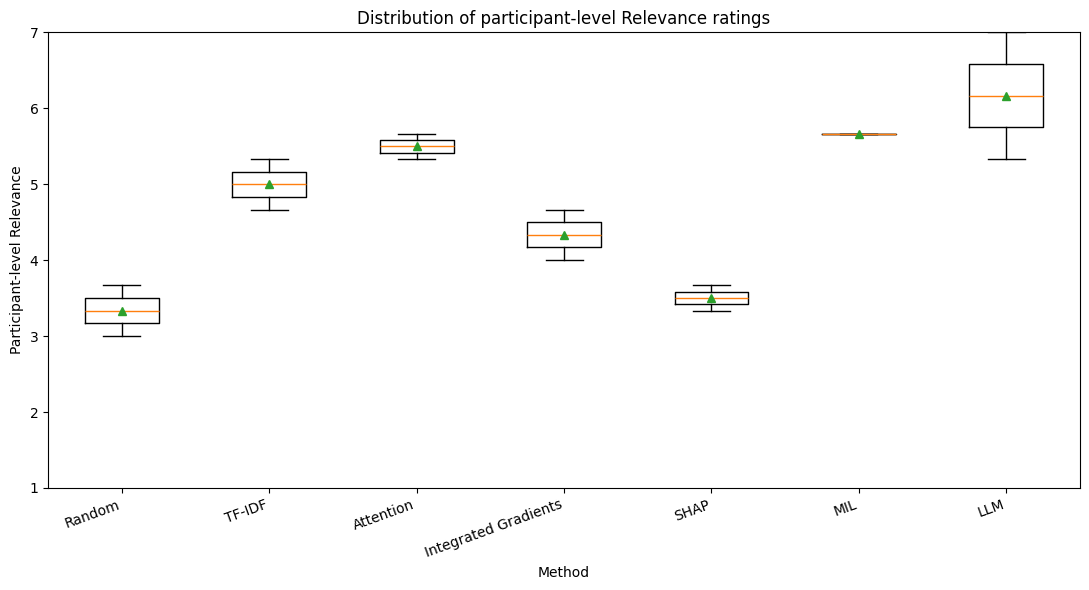

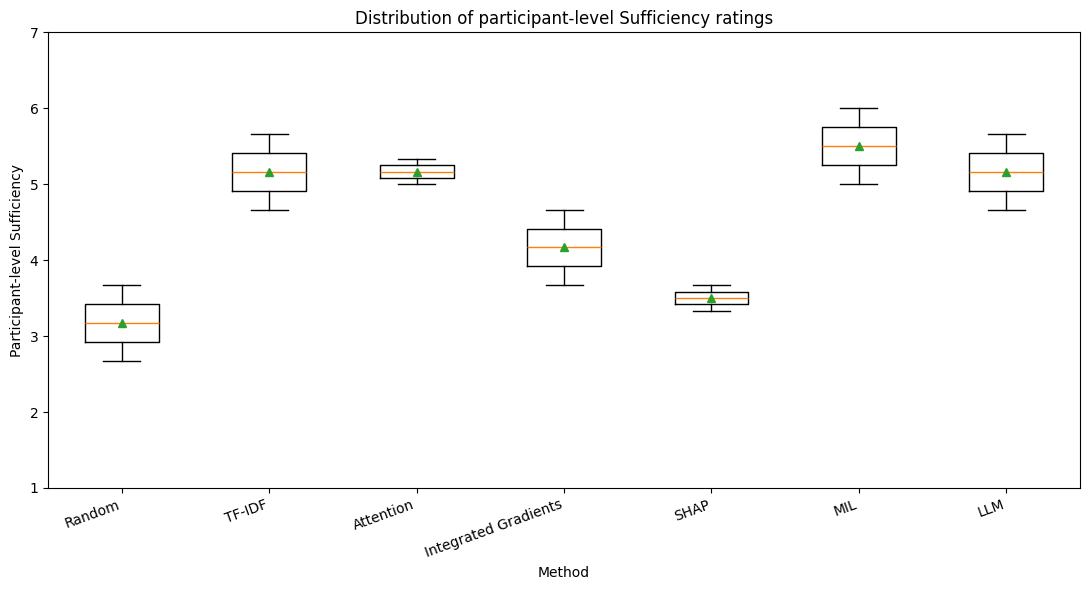

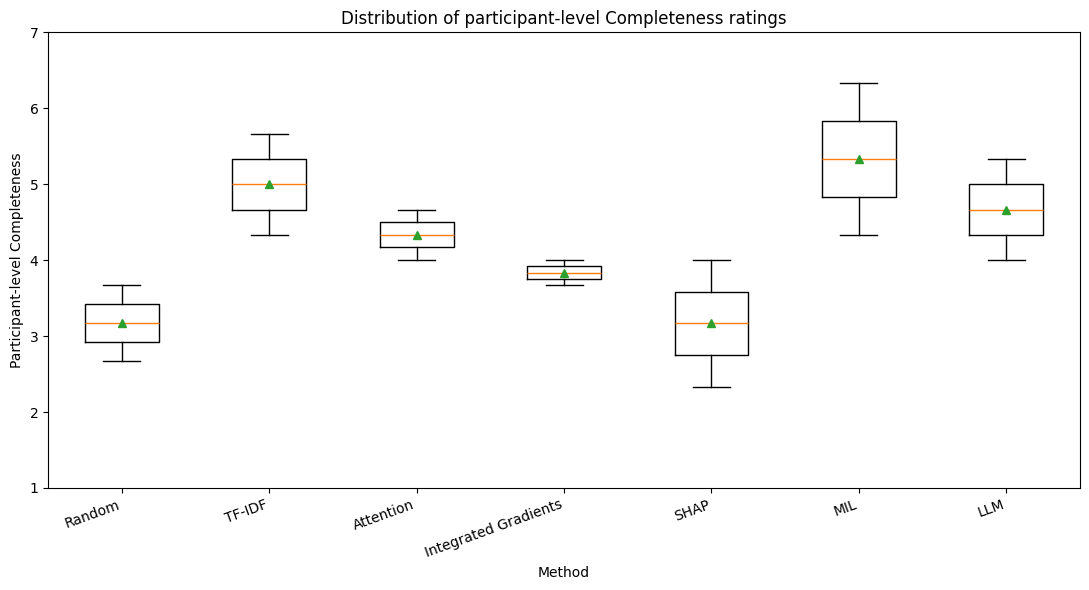

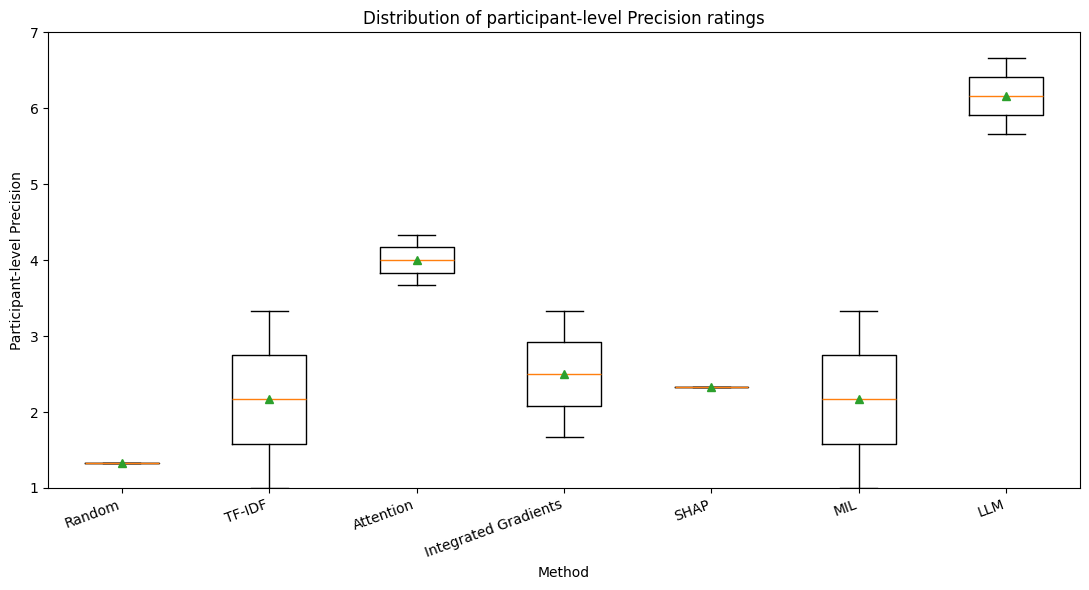

In [22]:

for criterion in CRITERIA:
    data = []
    labels = []

    for method in METHOD_ORDER:
        values = (
            participant_method.loc[
                participant_method["method_id"] == method,
                criterion,
            ]
            .dropna()
            .to_numpy()
        )

        if len(values) > 0:
            data.append(values)
            labels.append(METHOD_LABELS.get(method, method))

    plt.figure(figsize=(11, 6))
    plt.boxplot(data, tick_labels=labels, showmeans=True)
    plt.ylim(1, 7)
    plt.ylabel(f"Participant-level {CRITERION_LABELS[criterion]}")
    plt.xlabel("Method")
    plt.title(
        f"Distribution of participant-level {CRITERION_LABELS[criterion]} ratings"
    )
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / f"{criterion}_by_method_boxplot.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 4. Participant-level variation

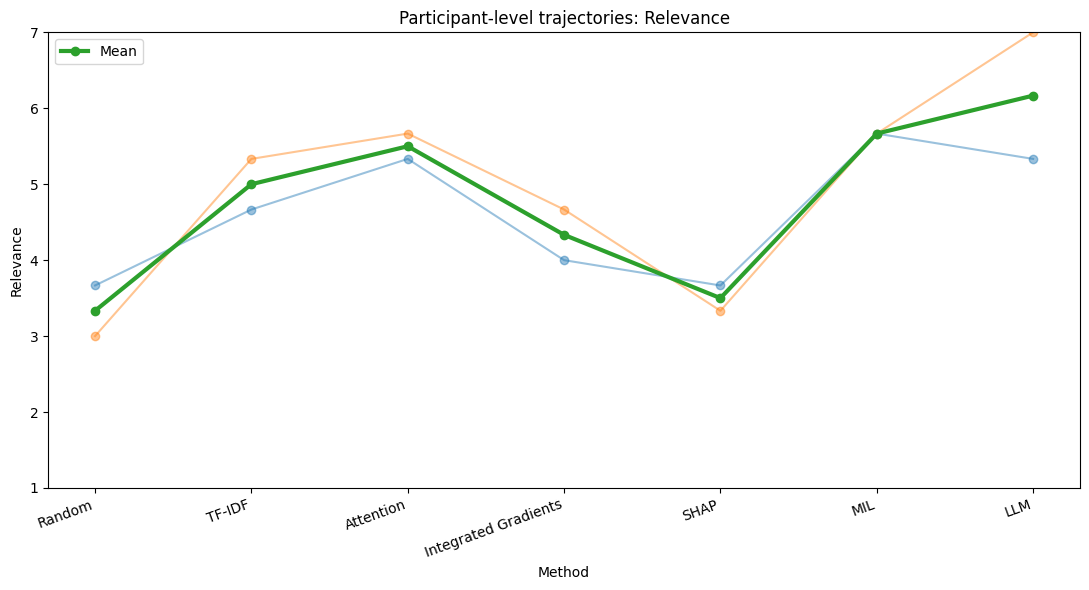

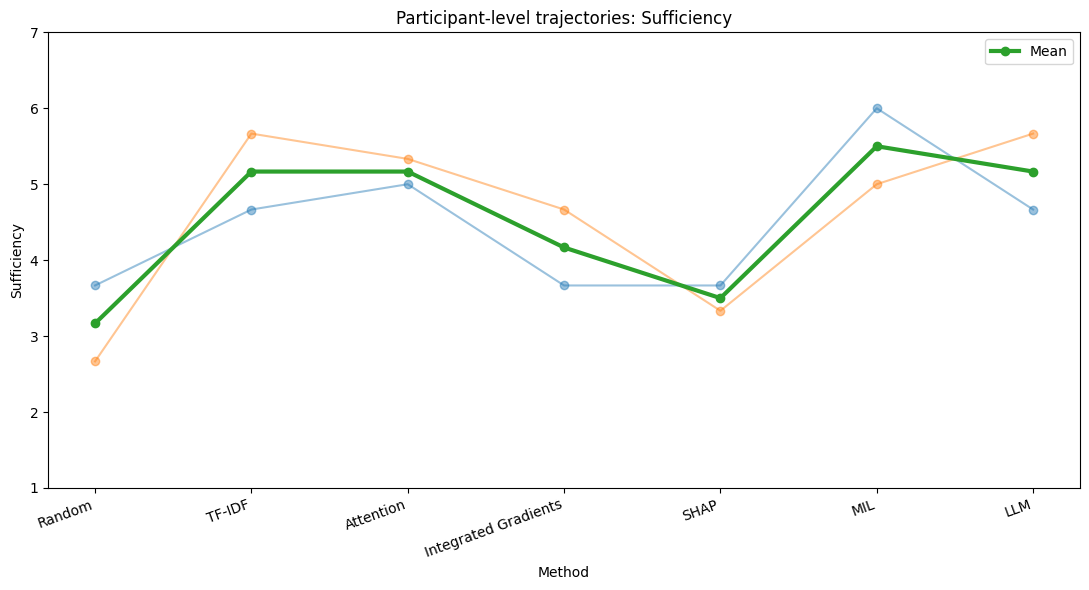

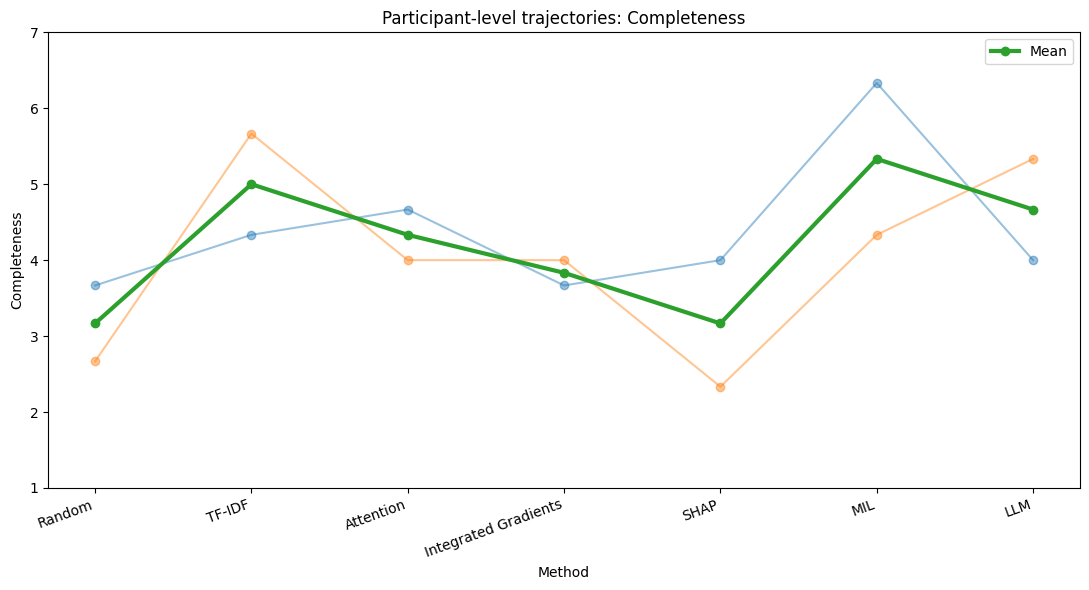

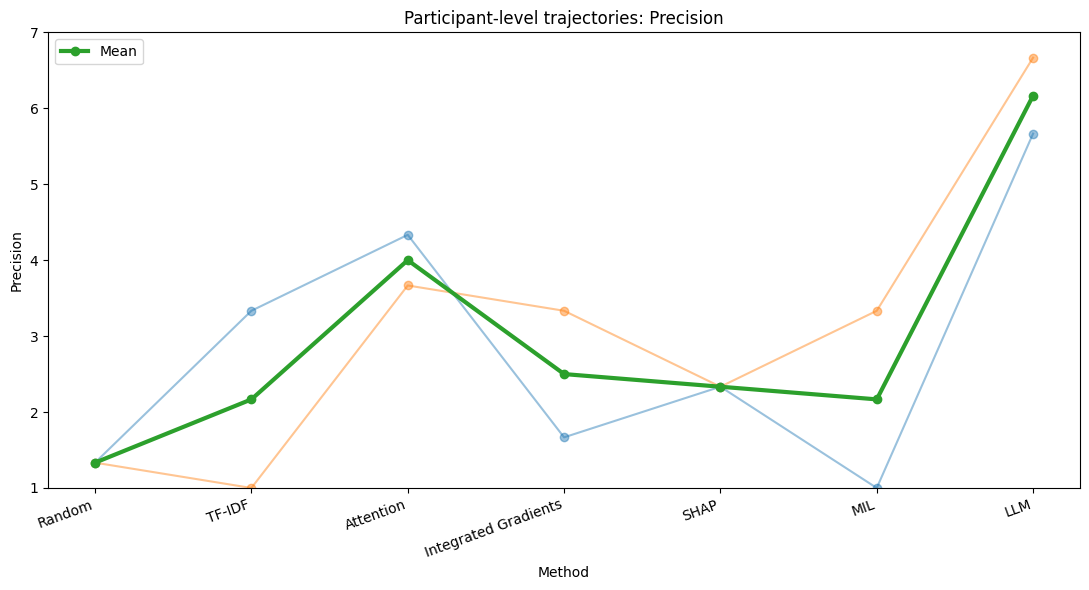

In [23]:

# One line per participant. Useful for seeing whether the method ranking is
# driven by a small number of participants.

for criterion in CRITERIA:
    pivot = (
        participant_method
        .pivot(index="response_id", columns="method_id", values=criterion)
        .reindex(columns=METHOD_ORDER)
    )

    plt.figure(figsize=(11, 6))

    for _, row in pivot.iterrows():
        plt.plot(
            [METHOD_LABELS[m] for m in METHOD_ORDER],
            row.values,
            marker="o",
            alpha=0.45,
        )

    mean_values = pivot.mean(axis=0)
    plt.plot(
        [METHOD_LABELS[m] for m in METHOD_ORDER],
        mean_values.values,
        marker="o",
        linewidth=3,
        label="Mean",
    )

    plt.ylim(1, 7)
    plt.ylabel(CRITERION_LABELS[criterion])
    plt.xlabel("Method")
    plt.title(
        f"Participant-level trajectories: {CRITERION_LABELS[criterion]}"
    )
    plt.xticks(rotation=20, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / f"{criterion}_participant_trajectories.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 5. Argument-level variation

In [24]:

argument_method = (
    ratings.groupby(["global_row_id", "method_id"], as_index=False)[CRITERIA]
    .mean()
)

display(argument_method.head())


,global_row_id,method_id,relevance,sufficiency,completeness,precision
0,1785,ig,4.0,4.0,4.0,2.5
1,1785,llm,5.0,5.0,5.0,5.0
2,1785,mil,5.0,5.0,5.0,1.0
3,1785,random,4.0,4.0,4.0,1.0
4,1785,tfidf,4.0,4.0,4.0,1.0


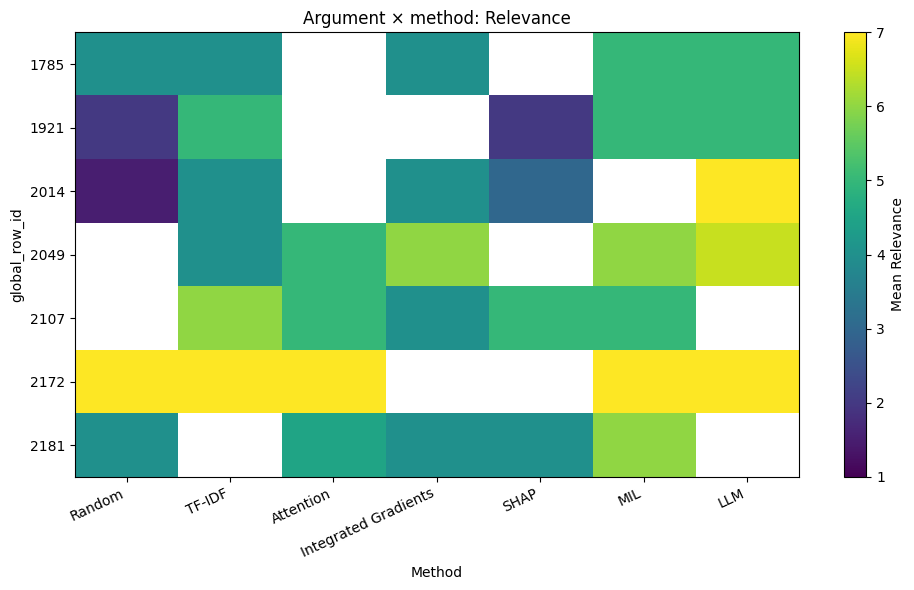

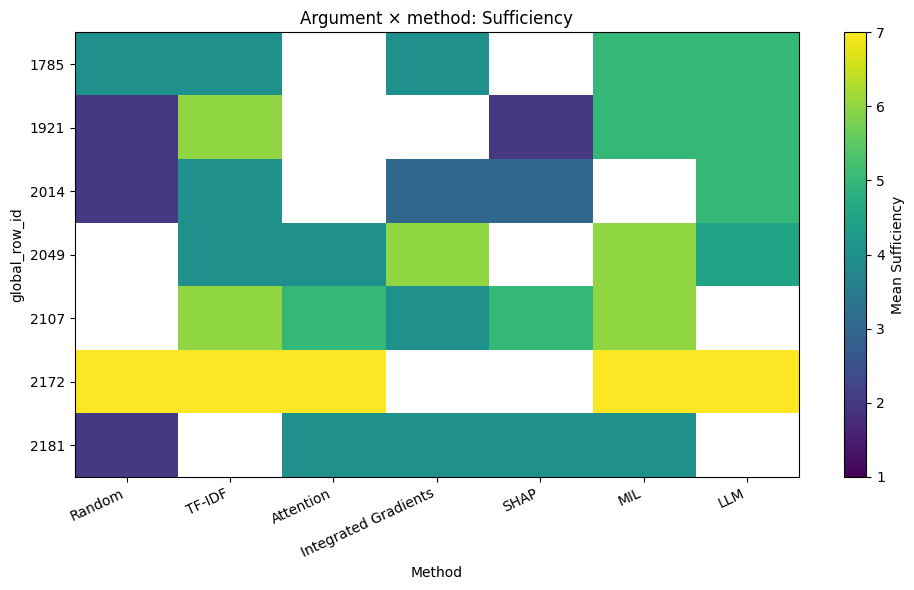

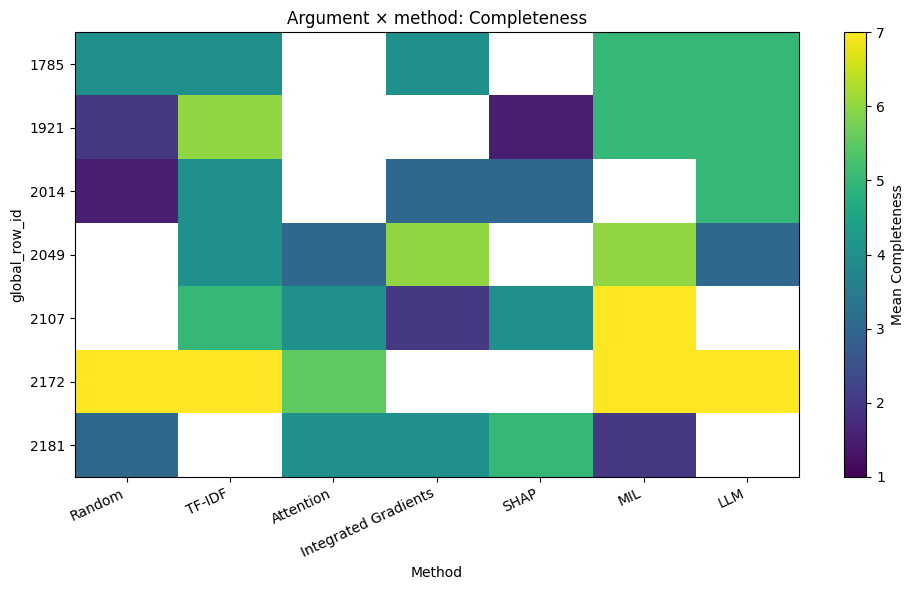

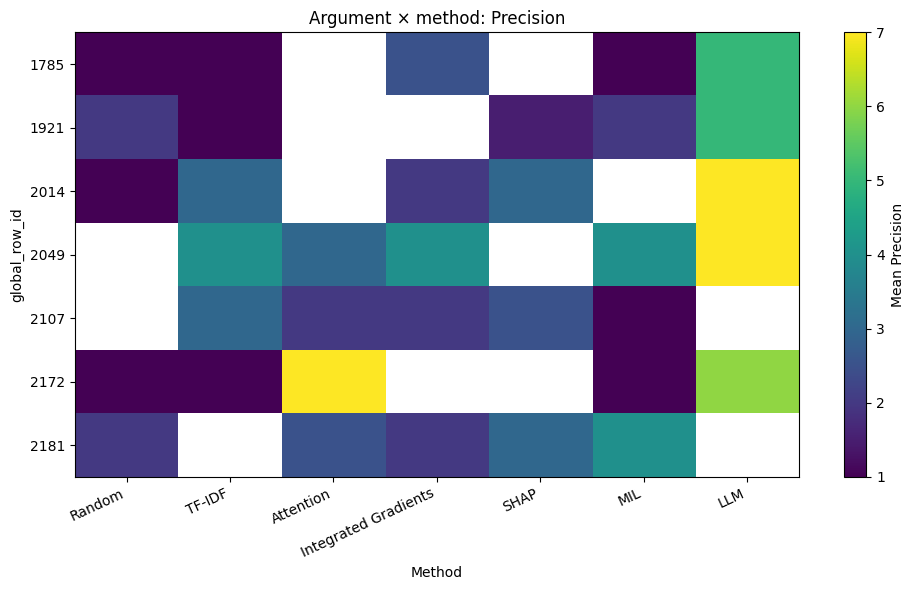

In [25]:

# Heatmap-like plot without seaborn: one figure per criterion.

for criterion in CRITERIA:
    pivot = (
        argument_method
        .pivot(index="global_row_id", columns="method_id", values=criterion)
        .reindex(columns=METHOD_ORDER)
    )

    plt.figure(figsize=(10, 6))
    image = plt.imshow(
        pivot.to_numpy(dtype=float),
        aspect="auto",
        vmin=1,
        vmax=7,
    )
    plt.colorbar(image, label=f"Mean {CRITERION_LABELS[criterion]}")

    plt.xticks(
        np.arange(len(METHOD_ORDER)),
        [METHOD_LABELS[m] for m in METHOD_ORDER],
        rotation=25,
        ha="right",
    )
    plt.yticks(
        np.arange(len(pivot.index)),
        pivot.index.astype(str),
    )

    plt.xlabel("Method")
    plt.ylabel("global_row_id")
    plt.title(
        f"Argument × method: {CRITERION_LABELS[criterion]}"
    )
    plt.tight_layout()
    plt.savefig(
        FIGURE_DIR / f"{criterion}_argument_method_heatmap.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 6. Method preference

In [26]:

# One preference decision per participant × argument.
preference_trials = (
    ratings[
        [
            "response_id",
            "version",
            "global_row_id",
            "display_position",
            "preferred_display_label",
            "preferred_method",
        ]
    ]
    .drop_duplicates(["response_id", "global_row_id"])
    .copy()
)

n_trials = len(preference_trials)
n_no_preference = preference_trials["preferred_method"].isna().sum()

print("Preference trials:", n_trials)
print("No preference:", n_no_preference)
print(
    "No-preference rate:",
    n_no_preference / n_trials if n_trials else np.nan,
)

preference_counts = (
    preference_trials["preferred_method"]
    .value_counts()
    .reindex(METHOD_ORDER, fill_value=0)
)

# Number of times each method was shown.
appearance_counts = (
    ratings.groupby("method_id")
    .size()
    .reindex(METHOD_ORDER, fill_value=0)
)

preference_summary = pd.DataFrame(
    {
        "method_id": METHOD_ORDER,
        "method": [METHOD_LABELS[m] for m in METHOD_ORDER],
        "times_displayed": appearance_counts.values,
        "times_preferred": preference_counts.values,
    }
)

preference_summary["preference_rate_when_displayed"] = (
    preference_summary["times_preferred"]
    / preference_summary["times_displayed"]
)

display(preference_summary)

preference_summary.to_csv(
    TABLE_DIR / "method_preference_summary.csv",
    index=False,
)


Preference trials: 14
No preference: 1
No-preference rate: 0.07142857142857142


,method_id,method,times_displayed,times_preferred,preference_rate_when_displayed
0,random,Random,6,0,0.000000
1,tfidf,TF-IDF,6,2,0.333333
2,attention,Attention,6,3,0.500000
3,ig,Integrated Gradients,6,0,0.000000
4,shap,SHAP,6,1,0.166667
5,mil,MIL,6,3,0.500000
6,llm,LLM,6,4,0.666667


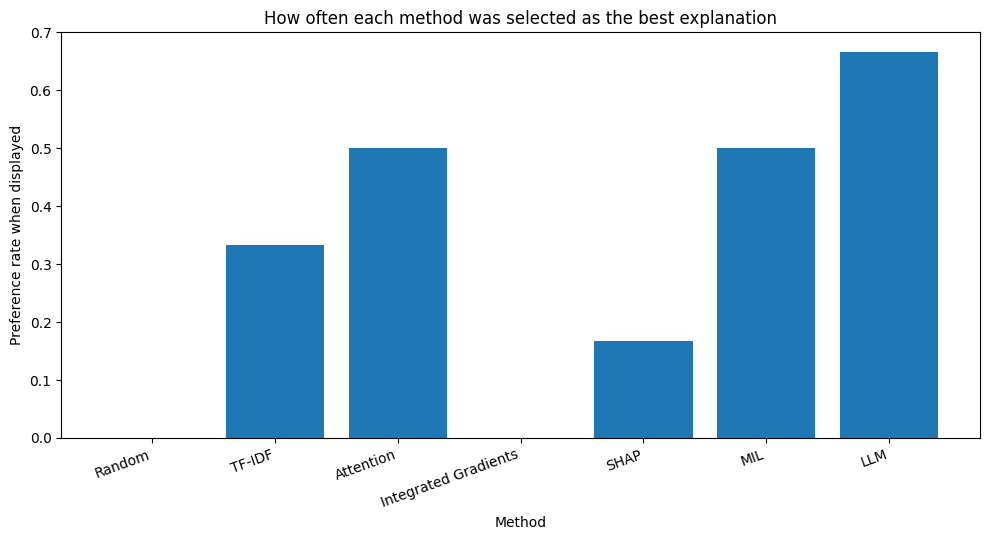

In [27]:

plt.figure(figsize=(10, 5.5))
plt.bar(
    preference_summary["method"],
    preference_summary["preference_rate_when_displayed"],
)
plt.ylabel("Preference rate when displayed")
plt.xlabel("Method")
plt.title("How often each method was selected as the best explanation")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "method_preference_rate.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()



### Preference by participant

This shows whether a method's overall preference count is broadly shared or concentrated in individual participants.


In [28]:

participant_preferences = (
    preference_trials.dropna(subset=["preferred_method"])
    .groupby(["response_id", "preferred_method"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=METHOD_ORDER, fill_value=0)
)

display(participant_preferences)


preferred_method,random,tfidf,attention,ig,shap,mil,llm
response_id,,,,,,,
2,0,2,3,0,0,0,2
3,0,0,0,0,1,3,2


## 7. Relation between perceived argument inappropriateness and explanation ratings

In [29]:

correlation_rows = []

for criterion in CRITERIA:
    subset = ratings[
        ["overall_inappropriateness", criterion]
    ].dropna()

    if len(subset) >= 3:
        rho, p_value = stats.spearmanr(
            subset["overall_inappropriateness"],
            subset[criterion],
        )
    else:
        rho, p_value = np.nan, np.nan

    correlation_rows.append(
        {
            "criterion": CRITERION_LABELS[criterion],
            "spearman_rho": rho,
            "p_value": p_value,
            "n": len(subset),
        }
    )

overall_rating_correlations = pd.DataFrame(correlation_rows)
display(overall_rating_correlations)

overall_rating_correlations.to_csv(
    TABLE_DIR / "overall_inappropriateness_correlations.csv",
    index=False,
)


,criterion,spearman_rho,p_value,n
0,Relevance,0.490153,0.000984,42
1,Sufficiency,0.444886,0.003157,42
2,Completeness,0.320067,0.038793,42
3,Precision,0.231028,0.141008,42



## 8. Exploratory repeated-measures comparison

Because the expected number of participants is small, these tests should be interpreted cautiously and reported together with the descriptive distributions.

Each participant contributes one mean score per method. The Friedman test compares all seven methods within participants. It is non-parametric and therefore a reasonable exploratory complement for the ordinal rating scale.

Note that the methods are evaluated on balanced but not necessarily identical argument subsets within each participant. The test therefore does **not** replace a fuller mixed-effects analysis if a larger sample becomes available.


In [30]:

friedman_rows = []

for criterion in CRITERIA:
    pivot = (
        participant_method
        .pivot(index="response_id", columns="method_id", values=criterion)
        .reindex(columns=METHOD_ORDER)
        .dropna()
    )

    if len(pivot) >= 2:
        result = stats.friedmanchisquare(
            *[pivot[method].values for method in METHOD_ORDER]
        )
        statistic = result.statistic
        p_value = result.pvalue
    else:
        statistic = np.nan
        p_value = np.nan

    friedman_rows.append(
        {
            "criterion": CRITERION_LABELS[criterion],
            "n_participants_complete": len(pivot),
            "friedman_chi2": statistic,
            "p_value": p_value,
        }
    )

friedman_results = pd.DataFrame(friedman_rows)
display(friedman_results)

friedman_results.to_csv(
    TABLE_DIR / "friedman_tests.csv",
    index=False,
)


,criterion,n_participants_complete,friedman_chi2,p_value
0,Relevance,2,11.449541,0.075438
1,Sufficiency,2,9.735849,0.136226
2,Completeness,2,8.587156,0.198162
3,Precision,2,8.594595,0.197694



### Optional pairwise Wilcoxon comparisons with Holm correction

These comparisons are exploratory. With only a small number of participants, p-values will have low power and should not replace effect-size and distribution plots.


In [31]:

def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    m = len(p_values)
    order = np.argsort(p_values)

    adjusted = np.empty(m, dtype=float)
    running_max = 0.0

    for rank, idx in enumerate(order):
        value = (m - rank) * p_values[idx]
        running_max = max(running_max, value)
        adjusted[idx] = min(running_max, 1.0)

    return adjusted


pairwise_rows = []

for criterion in CRITERIA:
    pivot = (
        participant_method
        .pivot(index="response_id", columns="method_id", values=criterion)
        .reindex(columns=METHOD_ORDER)
    )

    criterion_rows = []

    for i, method_a in enumerate(METHOD_ORDER):
        for method_b in METHOD_ORDER[i + 1:]:
            pair = pivot[[method_a, method_b]].dropna()

            if len(pair) < 2:
                statistic = np.nan
                p_value = np.nan
            else:
                differences = pair[method_a] - pair[method_b]

                if np.allclose(differences, 0):
                    statistic = 0.0
                    p_value = 1.0
                else:
                    result = stats.wilcoxon(
                        pair[method_a],
                        pair[method_b],
                        alternative="two-sided",
                    )
                    statistic = result.statistic
                    p_value = result.pvalue

            criterion_rows.append(
                {
                    "criterion": CRITERION_LABELS[criterion],
                    "method_a": method_a,
                    "method_b": method_b,
                    "n": len(pair),
                    "mean_a": pair[method_a].mean() if len(pair) else np.nan,
                    "mean_b": pair[method_b].mean() if len(pair) else np.nan,
                    "mean_difference": (
                        (pair[method_a] - pair[method_b]).mean()
                        if len(pair)
                        else np.nan
                    ),
                    "wilcoxon_statistic": statistic,
                    "p_value": p_value,
                }
            )

    valid_p = [
        row["p_value"]
        for row in criterion_rows
        if pd.notna(row["p_value"])
    ]

    if valid_p:
        adjusted = holm_adjust(valid_p)
        j = 0
        for row in criterion_rows:
            if pd.notna(row["p_value"]):
                row["p_holm"] = adjusted[j]
                j += 1
            else:
                row["p_holm"] = np.nan
    else:
        for row in criterion_rows:
            row["p_holm"] = np.nan

    pairwise_rows.extend(criterion_rows)

pairwise_results = pd.DataFrame(pairwise_rows)
display(pairwise_results)

pairwise_results.to_csv(
    TABLE_DIR / "pairwise_wilcoxon_holm.csv",
    index=False,
)


,criterion,method_a,method_b,n,mean_a,mean_b,mean_difference,wilcoxon_statistic,p_value,p_holm
0,Relevance,random,tfidf,2,3.333333,5.000000,-1.666667,0.0,0.5,1.0
1,Relevance,random,attention,2,3.333333,5.500000,-2.166667,0.0,0.5,1.0
2,Relevance,random,ig,2,3.333333,4.333333,-1.000000,0.0,0.5,1.0
3,Relevance,random,shap,2,3.333333,3.500000,-0.166667,0.0,1.0,1.0
4,Relevance,random,mil,2,3.333333,5.666667,-2.333333,0.0,0.5,1.0
...,...,...,...,...,...,...,...,...,...,...
79,Precision,ig,mil,2,2.500000,2.166667,0.333333,0.0,1.0,1.0
80,Precision,ig,llm,2,2.500000,6.166667,-3.666667,0.0,0.5,1.0
81,Precision,shap,mil,2,2.333333,2.166667,0.166667,1.0,1.0,1.0
82,Precision,shap,llm,2,2.333333,6.166667,-3.833333,0.0,0.5,1.0


## 9. Compact thesis tables

In [32]:

# Compact mean ± SD table based on participant-level method means.

compact = (
    participant_method
    .groupby("method_id")[CRITERIA]
    .agg(["mean", "std"])
    .reindex(METHOD_ORDER)
)

display(compact)

compact.to_csv(
    TABLE_DIR / "compact_method_mean_sd.csv"
)


relevance           sufficiency           completeness            \
               mean       std        mean       std         mean       std   
method_id                                                                    
random     3.333333  0.471405    3.166667  0.707107     3.166667  0.707107   
tfidf      5.000000  0.471405    5.166667  0.707107     5.000000  0.942809   
attention  5.500000  0.235702    5.166667  0.235702     4.333333  0.471405   
ig         4.333333  0.471405    4.166667  0.707107     3.833333  0.235702   
shap       3.500000  0.235702    3.500000  0.235702     3.166667  1.178511   
mil        5.666667  0.000000    5.500000  0.707107     5.333333  1.414214   
llm        6.166667  1.178511    5.166667  0.707107     4.666667  0.942809   

          precision            
               mean       std  
method_id                      
random     1.333333  0.000000  
tfidf      2.166667  1.649916  
attention  4.000000  0.471405  
ig         2.500000  1.178511  
shap       2.333333  0.000000  
mil        2.166667  1.649916  
llm        6.166667  0.707107

In [33]:

# Mean ratings in a simple methods × criteria table.

mean_table = (
    participant_method
    .groupby("method_id")[CRITERIA]
    .mean()
    .reindex(METHOD_ORDER)
    .rename(index=METHOD_LABELS, columns=CRITERION_LABELS)
)

display(mean_table.round(3))

mean_table.round(3).to_csv(
    TABLE_DIR / "method_means.csv"
)


,Relevance,Sufficiency,Completeness,Precision
method_id,,,,
Random,3.333,3.167,3.167,1.333
TF-IDF,5.000,5.167,5.000,2.167
Attention,5.500,5.167,4.333,4.000
Integrated Gradients,4.333,4.167,3.833,2.500
SHAP,3.500,3.500,3.167,2.333
MIL,5.667,5.500,5.333,2.167
LLM,6.167,5.167,4.667,6.167



## 10. Generated outputs

Figures are stored in:

`human_study/survey_results/figures/`

Compact analysis tables are stored in:

`human_study/survey_results/analysis_tables/`

The most useful outputs for the thesis will likely be:

- `method_ratings_all_criteria.png`
- one `*_by_method_mean_ci.png` figure per criterion
- `method_preference_rate.png`
- `method_rating_summary.csv`
- `method_preference_summary.csv`
- `friedman_tests.csv`

For the final thesis analysis, the descriptive participant-level summaries should remain the primary result. Inferential tests are best treated as exploratory if the final number of participants remains small.
